# Pathology gallery

One section per pathology. Every section follows the same shape: the vignette (a fictional short-video app; all data synthetic), the ground truth set by construction, the naive analysis's quantified error, and the corrected method's recovery. Each figure here is the same code path as `scripts/regenerate_figures.py`, and each number is asserted against theory in `tests/integration/test_pathologies.py`.

In [1]:
import numpy as np

from lab.assignment import assign_clusters, assign_users
from lab.pathologies import (
    effect_path,
    simulate_contamination,
    simulate_daily_peeking,
    simulate_interference,
    simulate_many_metrics,
    simulate_novelty,
    simulate_subgroup_fishing,
)
from lab.populations import continuous_users
from lab.populations.graphs import sbm_graph
from lab.reporting import (
    fig_contamination,
    fig_interference,
    fig_multiple_comparisons,
    fig_novelty,
    fig_peeking,
    fig_subgroups,
)

## Peeking: checking daily manufactures false positives

A growth PM watches the dashboard every morning and calls the test at the first green p-value. 4,000 replications of a 14-day experiment with **no true effect**: the naive policy rejects far above the nominal 5%; the Lan-DeMets O'Brien-Fleming boundary restores it.

In [2]:
peek = simulate_daily_peeking(n_sims=4000, n_days=14, effect=0.0, seed=1)
print(peek.rejection_rates().round(4))

fixed_horizon    0.0498
naive_peeking    0.2408
sequential       0.0495
dtype: float64


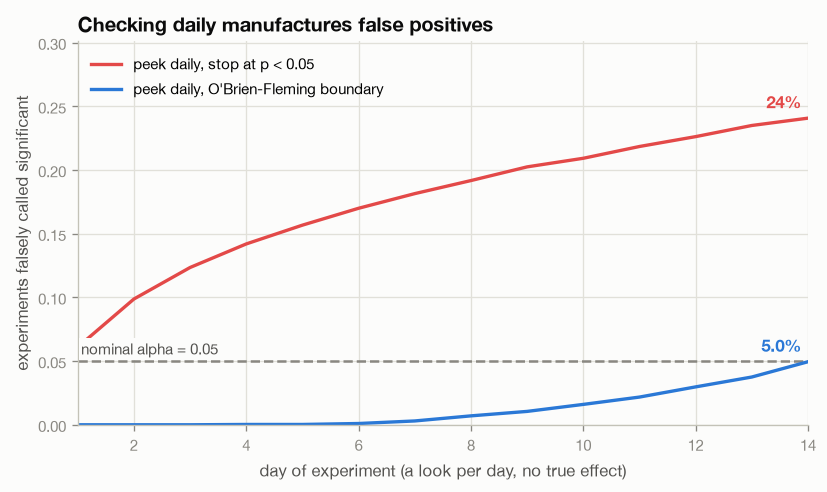

In [3]:
fig, _ = fig_peeking(peek)

## Multiple comparisons: twenty metrics, one experiment

The dashboard tracks 20 metrics, all null here. Testing each at 0.05 finds 'something significant' in most experiments. Bonferroni and Benjamini-Hochberg both control their target rates; the difference is power, shown in the pathology tests with true effects present.

In [4]:
multi = simulate_many_metrics(n_sims=4000, n_metrics=20, seed=3)
print(multi.summary.round(4))

                      fwer     fdr  power
naive               0.6288  0.6288    NaN
bonferroni          0.0470  0.0470    NaN
benjamini_hochberg  0.0480  0.0480    NaN


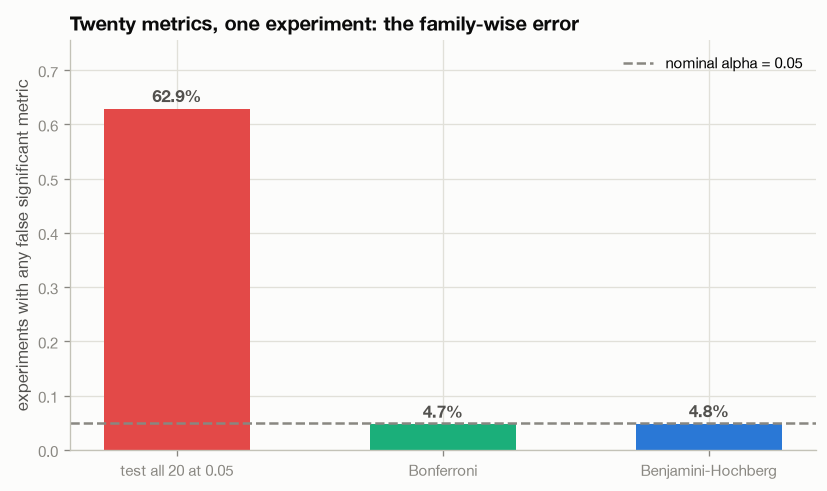

In [5]:
fig, _ = fig_multiple_comparisons(multi)

## Contamination: assignment is not receipt

20% of treatment never receives the feature, 10% of control is exposed (shared devices), and receipt correlates with baseline engagement. True effect 0.50. Intent-to-treat attenuates; per-protocol inflates via selection; IV/Wald divides ITT by the compliance gap and recovers it. Expected values are closed-form from the latent baselines.

In [6]:
users = continuous_users(100_000, seed=6)
treated = assign_users(users, seed=7)
contam = simulate_contamination(users, treated, effect=0.5, seed=8)
print('estimates', dict(contam.estimates.round(3)))
print('expected ', dict(contam.expected.round(3)))

estimates {'intent_to_treat': np.float64(0.378), 'per_protocol': np.float64(0.846), 'iv_wald': np.float64(0.54)}
expected  {'intent_to_treat': np.float64(0.345), 'per_protocol': np.float64(0.834), 'iv_wald': np.float64(0.493)}


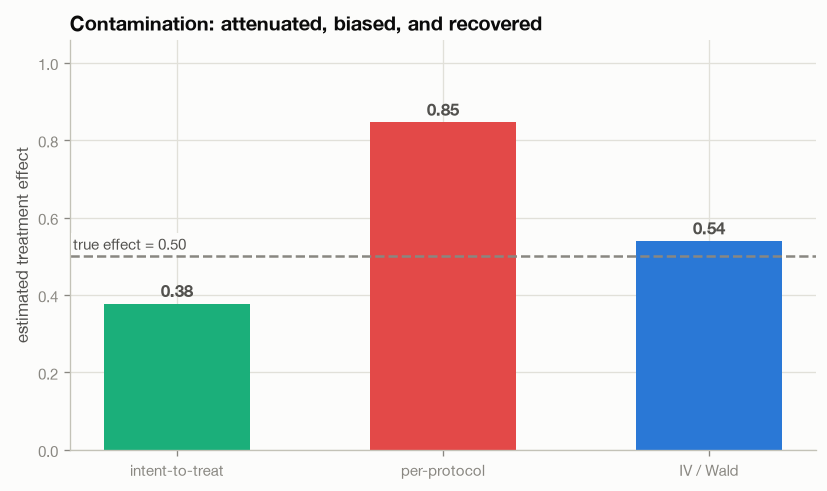

In [7]:
fig, _ = fig_contamination(contam)

## Interference: the design decides what the estimator can see

A sharing feature leaks through the follow graph (stochastic block model, 100 clusters). Direct effect 0.5, spillover 0.3, so the global treatment effect is 0.8. Under user-level randomization both arms have ~50% treated neighbors and the estimator reads only the direct effect; cluster randomization pushes the exposure contrast near 1 and recovers the global effect. The expected row is the exact linear-in-means identity, not a Monte Carlo average.

In [8]:
net_users = continuous_users(20_000, seed=9)
adjacency, clusters = sbm_graph(20_000, n_clusters=100, seed=10)
net_users['cluster'] = clusters
interf = simulate_interference(
    net_users, adjacency,
    assign_users(net_users, seed=11),
    assign_clusters(net_users, cluster_col='cluster', seed=11),
    direct=0.5, spillover=0.3, seed=12,
)
print('estimates', dict(interf.estimates.round(3)))
print('expected ', dict(interf.expected.round(3)))
print('exposure contrast', dict(interf.exposure_contrast.round(3)))

estimates {'user_randomized': np.float64(0.52), 'cluster_randomized': np.float64(0.83)}
expected  {'user_randomized': np.float64(0.512), 'cluster_randomized': np.float64(0.797)}
exposure contrast {'user_randomized': np.float64(0.003), 'cluster_randomized': np.float64(0.952)}


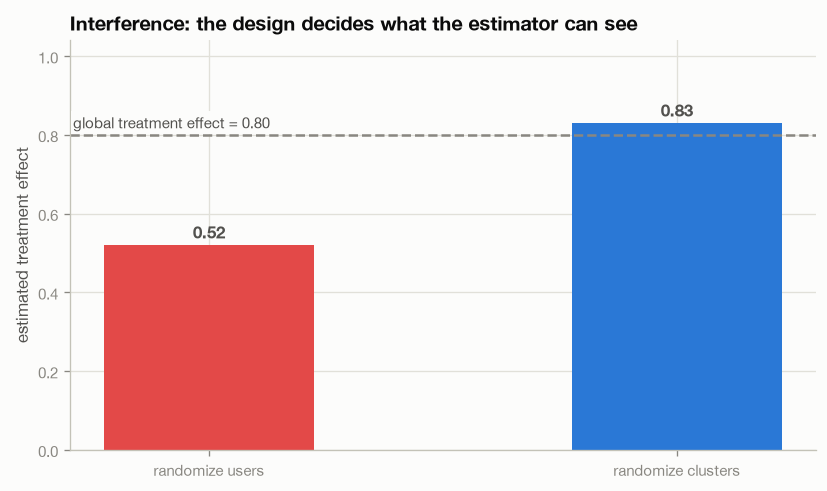

In [9]:
fig, _ = fig_interference(interf)

## Subgroup fishing: significant in Brazil, probably noise

Topline flat, so someone scans 20 country segments, all null here. The scan finds at least one 'significant' subgroup in ~64% of experiments. A pre-registered primary stays at 5%; a Benjamini-Hochberg-corrected scan stays controlled.

In [10]:
sub = simulate_subgroup_fishing(n_sims=4000, n_segments=20, seed=13)
print(sub.summary.round(4))

fishing_any_discovery                       0.6378
fishing_false_discoveries_per_experiment    1.0110
preregistered_primary_fpr                   0.0495
bh_corrected_any_discovery                  0.0522
dtype: float64


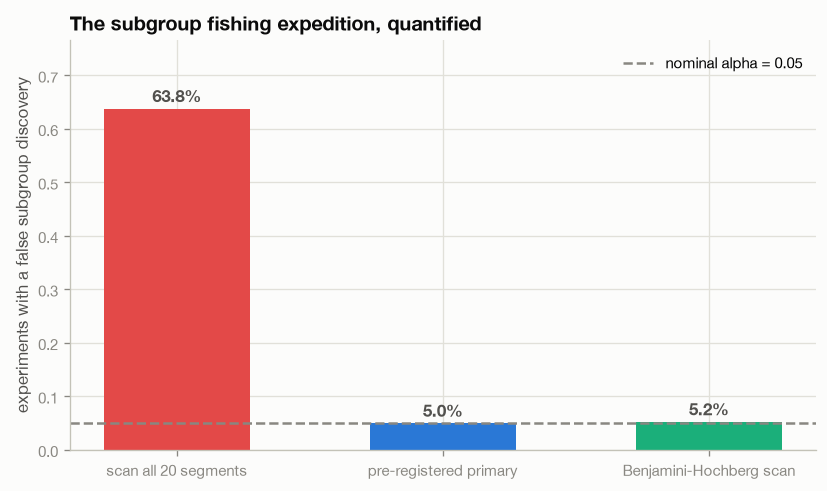

In [11]:
fig, _ = fig_subgroups(sub)

## Novelty: the first week is not the launch effect

New feed layout: long-run effect 0.10 plus a 0.40 novelty spike decaying with a 5-day time constant. The week-1 readout overstates the launch effect 3x; the 4-week average still overstates; the post-burn-in window sits near the truth. Window expectations are the analytic means of the effect path.

In [12]:
nov = simulate_novelty(seed=15)
print('estimates', dict(nov.estimates.round(3)))
print('expected ', dict(nov.expected.round(3)))
print('long-run truth', nov.long_run_effect)

estimates {'first_week': np.float64(0.318), 'full_run': np.float64(0.19), 'post_burn_in': np.float64(0.131)}
expected  {'first_week': np.float64(0.338), 'full_run': np.float64(0.179), 'post_burn_in': np.float64(0.104)}
long-run truth 0.1


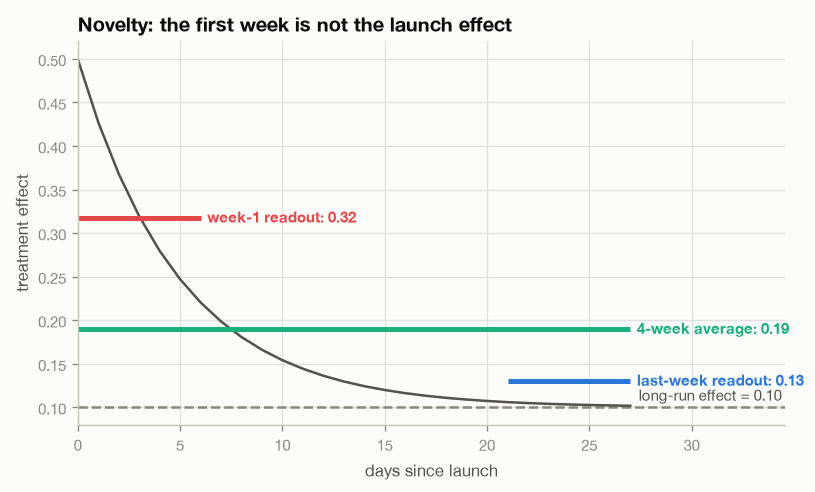

In [13]:
days = np.arange(28)
path = effect_path(days, long_run=0.10, novelty_amplitude=0.40, decay_days=5.0)
fig, _ = fig_novelty(nov, path_days=days, path=path)